In [1]:
# Checking torch and torchvision version 
import torch 
import torchvision 

print(torch.__version__)
print(torchvision.__version__)

2.6.0
0.21.0


#### 1. Importing necessary libraries 

In [2]:
import torch 
import torchvision
import matplotlib.pyplot as plt 
from torch import nn
from torchvision import transforms

# try importing summary from torchinfo 
try: 
    from torchinfo import summary 
except: 
    print("['INFO] couldn't find ... Downloading it.")
    !pip install -q torchinfo 
    from torchinfo import summary 
    
# try importing our 05_going_modular scripts 
try: 
    from going_modular.going_modular import data_setup, engine 
except: 
    print("\nCouldn't find going_modular ... Downloading from github")
    !git clone "https://github.com/Abisheklimbu/pytorch.git"
    !mv pytorch/going_modular . 
    !rm -rf pytorch
    from  going_modular.going_modular import data_setup, engine 
    

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

#### 2. Get Data

In [ ]:
import os
import zipfile

from pathlib import Path

import requests

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/Abisheklimbu/pytorch/raw/refs/heads/main/data_creation/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / "pizza_steak_sushi.zip")

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


In [5]:
train_dir = image_path/"train"
test_dir = image_path/"test"

#### 3. Create dataset and dataloaders 

In [6]:
# manual_transforms 
manual_transforms = torchvision.transforms.Compose([
    transforms.Resize((224,224)), 
    transforms.ToTensor(), 
    transforms.Normalize(mean= [0.485, 0.456, 0.406], 
                        std= [0.229, 0.224, 0.225])
])
manual_transforms

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [7]:
# auto_transforms
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [8]:
train_dataloader, test_dataloader, num_classes = data_setup.create_dataloaders(train_dir=train_dir, 
                                                                              test_dir=test_dir, 
                                                                              transform=auto_transforms, 
                                                                              batch_size=32)

In [9]:
train_dataloader, test_dataloader, num_classes

(<torch.utils.data.dataloader.DataLoader at 0x7aa7d469aed0>,
 ['pizza', 'steak', 'sushi'])

#### 4. Load pre-trained models 

In [10]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT 
model = torchvision.models.efficientnet_b0(weights=weights).to(device)
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

#### 5. Let's look at the summary and freeze features layers 

In [11]:
summary(model= model, 
        input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"], 
        col_width= 20,
        row_settings= ["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [12]:
# freeze features layers
for param in model.features.parameters():
    param.requires_grad= False

torch.manual_seed(42)
torch.cuda.manual_seed(42)
model.classifier = nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280, 
                   out_features=len(num_classes), 
                   bias=True).to(device)
)

In [13]:
# let's again print summary
summary(model=model, 
        input_size=(32,3,224,224), 
        verbose=0, 
        col_names=["input_size", "output_size", "num_params", "trainable"], 
        col_width=20, 
        row_settings=["var_names"]
       )

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

#### 6. Train model 

In [14]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [15]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
from timeit import default_timer as timer

start_timer = timer()
results = engine.train(model=model, 
                      train_dataloader=train_dataloader, 
                      test_dataloader=test_dataloader, 
                      loss_fn=loss_fn, 
                      optimizer=optimizer,
                      epochs=5, 
                      device=device)
end_timer = timer()
print(f"Total training time {end_timer-start_timer:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 3.5859 | train_acc: 9.8318 | test_loss: 6.8906 | test_acc: 7.8949
Epoch: 2 | train_loss: 7.3828 | train_acc: 6.7824 | test_loss: 7.7695 | test_acc: 6.2571
Epoch: 3 | train_loss: 6.9609 | train_acc: 5.9121 | test_loss: 7.0664 | test_acc: 5.4150
Epoch: 4 | train_loss: 6.9258 | train_acc: 5.0174 | test_loss: 7.1016 | test_acc: 5.0813
Epoch: 5 | train_loss: 7.4531 | train_acc: 4.4251 | test_loss: 7.2773 | test_acc: 4.0588
Total training time 19.723 seconds


In [16]:
results

{'train_loss': [3.5859375, 7.3828125, 6.9609375, 6.92578125, 7.453125],
 'train_acc': [9.83184340596199,
  6.782406248152256,
  5.912081189453602,
  5.017355237156153,
  4.42511111497879],
 'test_loss': [6.890625, 7.76953125, 7.06640625, 7.1015625, 7.27734375],
 'test_acc': [7.894899241626263,
  6.257073551416397,
  5.41497740149498,
  5.081329677253962,
  4.058816950768232]}

In [22]:
#### 7. Evaluate model by plotting loss and accuracy 

In [23]:
try: 
    from helper_function import plot_loss_curves

except: 
    print("Couldn't find. Downloading ...")
    with open("helper_function.py", "wb") as file:
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
        file.write(request.content)
    from helper_function import plot_loss_curves 

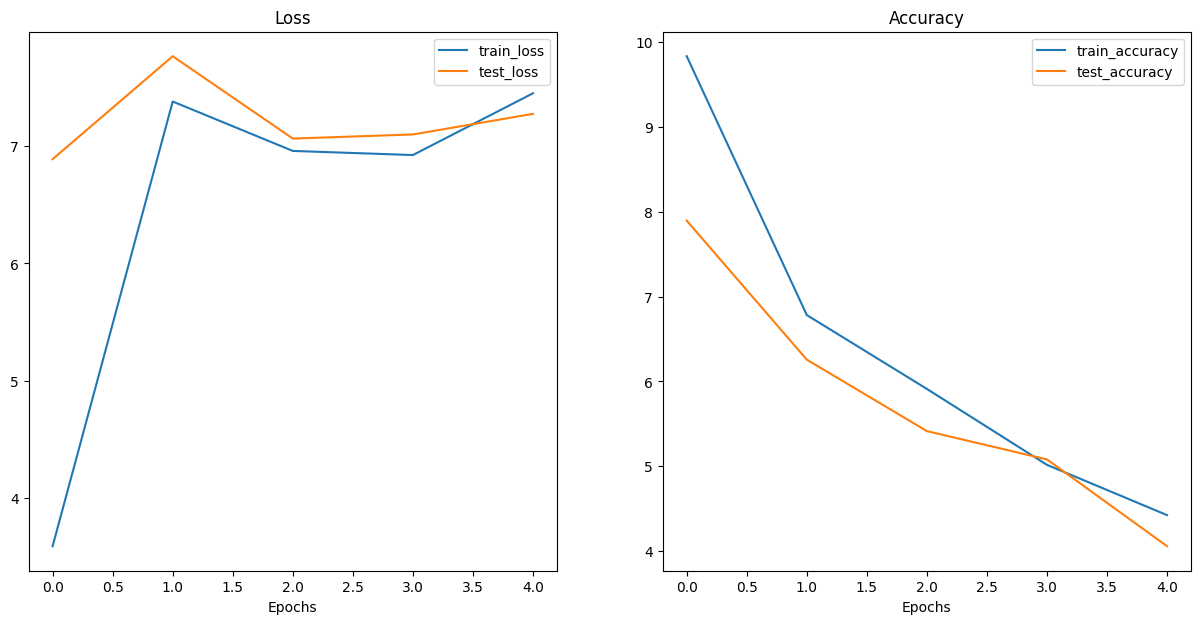

In [24]:
plot_loss_curves(results)

In [25]:
def plot_loss_curve(results): 
    train_loss = results["train_loss"]
    test_loss = results["test_loss"]

    train_acc = results["train_acc"]
    test_acc = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15,7))

    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label="train_acc")
    plt.plot(epochs, test_acc, label="test_acc")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

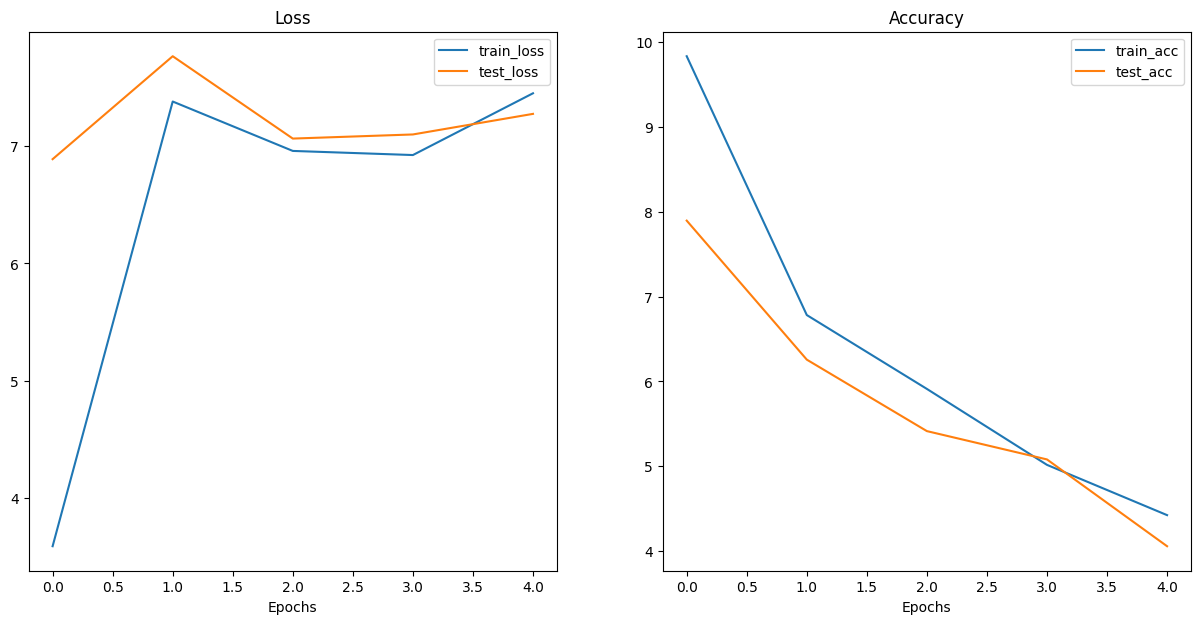

In [26]:
plot_loss_curve(results)